In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import shap

# 1. Simulação de Dados (Target: Propensão de Compra)
np.random.seed(42)
data = pd.DataFrame({
    'idade': np.random.randint(18, 70, 1000),
    'renda': np.random.normal(5000, 1500, 1000),
    'categoria_favorita': np.random.choice(['eletronicos', 'roupas', 'livros'], 1000),
    'dias_desde_ultimo_acesso': np.random.randint(1, 30, 1000),
    'comprou': np.random.choice([0, 1], 1000, p=[0.8, 0.2]) # Classes desbalanceadas
})

# Inserindo nulos aleatórios para demonstrar tratamento
data.loc[10:50, 'renda'] = np.nan

X = data.drop('comprou', axis=1)
y = data['comprou']

# 2. Train/Test Split (Separação rigorosa ANTES de qualquer transformação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Construção da Pipeline de Preprocessamento
numeric_features = ['idade', 'renda', 'dias_desde_ultimo_acesso']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputação robusta a outliers
    ('scaler', StandardScaler())                   # Previne peso desproporcional
])

categorical_features = ['categoria_favorita']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Lida com novas categorias em produção
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Pipeline Completa (Preprocessamento + Modelo)
# Uso de class_weight='balanced' para mitigar o desbalanceamento
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
])

# 5. Treinamento e Cross-Validation
# Usando validação cruzada para garantir estabilidade (sem leakage, pois a pipeline roda a cada fold)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"ROC-AUC em Cross-Validation (Média): {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Treino final no conjunto inteiro de treino
model_pipeline.fit(X_train, y_train)

# 6. Avaliação Out-of-Sample (Teste)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("\nRelatório de Classificação (Test Set):")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC (Test Set): {roc_auc_score(y_test, y_proba):.3f}")

# 7. Interpretabilidade com SHAP (Opcional, focado no modelo dentro da pipeline)
# Extraímos os dados transformados para explicar o modelo
X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)
rf_model = model_pipeline.named_steps['classifier']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)


ROC-AUC em Cross-Validation (Média): 0.526 (+/- 0.072)

Relatório de Classificação (Test Set):
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       163
           1       0.20      0.35      0.25        37

    accuracy                           0.62       200
   macro avg       0.51      0.52      0.50       200
weighted avg       0.71      0.62      0.65       200

ROC-AUC (Test Set): 0.490


# Modelo de Propensão de Compra — Pipeline Elaborado (Feature Engineering, Avaliação Aprofundada e SHAP)

Este notebook expande o modelo básico original. A pedido, a base de dados simulada e **aleatória** foi mantida como estava (não existe relação real entre as features e o target `comprou`). Foram adicionados:

- **Feature engineering** dentro da própria pipeline (sem vazamento, reaplicada de forma idêntica em cada fold da validação cruzada);
- **Avaliação aprofundada**: PR-AUC, Brier score, matriz de confusão, curvas ROC/PR, estatística KS, curva de calibração, otimização de threshold e tabela de decis/lift;
- **Interpretabilidade avançada com SHAP**: importância global (summary plot e bar plot), dependence plot, e explicações locais (waterfall e force plot) comparando um cliente de alta propensão com um de baixa propensão.

⚠️ **Sobre os números:** como os dados são gerados aleatoriamente, é esperado que as métricas de ordenação (AUC, PR-AUC, KS) fiquem perto do nível de base, mesmo com um pipeline mais elaborado. O valor deste notebook está na técnica — o mesmo esqueleto se aplica integralmente quando a base tiver sinal real.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
import shap

%matplotlib inline
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Simulação e exploração rápida dos dados

Base sintética mantida como no notebook original (sem sinal real). Antes de modelar, vale sempre olhar a base: shape, nulos e balanceamento de classes.

In [3]:
# 1. Simulação de Dados (Target: Propensão de Compra)
# Aviso: os dados abaixo são 100% aleatórios -- não existe relação real entre
# as features e o target 'comprou'. Isso é proposital (mantido a pedido), então
# é esperado que as métricas de rank (AUC, PR-AUC, KS...) fiquem perto do nível
# de base, independentemente de quão elaborado o pipeline seja. O valor deste
# notebook está na TÉCNICA: feature engineering sem vazamento, validação
# cruzada estratificada, avaliação em múltiplas camadas e interpretabilidade --
# o mesmo esqueleto se aplica quando a base tiver sinal de verdade.
np.random.seed(RANDOM_STATE)
data = pd.DataFrame({
    'idade': np.random.randint(18, 70, 1000),
    'renda': np.random.normal(5000, 1500, 1000),
    'categoria_favorita': np.random.choice(['eletronicos', 'roupas', 'livros'], 1000),
    'dias_desde_ultimo_acesso': np.random.randint(1, 30, 1000),
    'comprou': np.random.choice([0, 1], 1000, p=[0.8, 0.2])  # Classes desbalanceadas
})

# Inserindo nulos aleatórios para demonstrar tratamento
data.loc[10:50, 'renda'] = np.nan

X = data.drop('comprou', axis=1)
y = data['comprou']

print(f"Shape: {data.shape}")
print(f"Taxa de positivos (comprou=1): {y.mean():.1%}")
print(f"\nNulos por coluna:\n{data.isna().sum()}")
data.describe(include='all').T

Shape: (1000, 5)
Taxa de positivos (comprou=1): 18.7%

Nulos por coluna:
idade                        0
renda                       41
categoria_favorita           0
dias_desde_ultimo_acesso     0
comprou                      0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idade,1000.0,NaN,NaN,NaN,43.819,14.99103,18.0,31.0,44.0,56.0,69.0
renda,959.0,NaN,NaN,NaN,5107.34956,1485.513002,655.616933,4111.666188,5096.711622,6061.895459,8948.573097
categoria_favorita,1000,3,eletronicos,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_desde_ultimo_acesso,1000.0,NaN,NaN,NaN,15.308,8.362001,1.0,8.0,16.0,23.0,29.0
comprou,1000.0,NaN,NaN,NaN,0.187,0.390107,0.0,0.0,0.0,0.0,1.0


## 2. Split treino/teste

Separação rigorosa **antes** de qualquer transformação ou feature engineering, para que nada do teste vaze para o ajuste do pipeline.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Taxa de positivos - treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")

Treino: 800 linhas | Teste: 200 linhas
Taxa de positivos - treino: 18.8% | teste: 18.5%


## 3. Feature engineering

Implementada como um `Transformer` do scikit-learn, para viver **dentro** da pipeline: isso garante que a mesma engenharia seja aplicada de forma idêntica em treino, em cada fold da validação cruzada e em produção — sem duplicar código e sem vazamento (nenhuma conta abaixo usa o target ou estatísticas globais da base; usa só limites de negócio fixos, aplicados linha a linha).

Features criadas:
- `renda_log`: reduz o efeito de valores extremos de renda na escala original;
- `renda_por_idade`: poder de compra relativo à idade (interação);
- `engajamento_score`: recência transformada (1 / dias desde o último acesso), para não forçar o modelo a linearizar uma relação que não é linear;
- `faixa_etaria` e `recencia_categoria`: cortes de negócio comuns em campanhas de CRM, úteis também para leitura/comunicação dos resultados.

In [5]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cria features derivadas a partir das colunas brutas.
    Vive dentro da pipeline: fit() não faz nada (stateless), então pode ser
    reaplicada em qualquer fold/conjunto sem risco de vazamento.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Log da renda: reduz o efeito de valores extremos na escala original
        X['renda_log'] = np.log1p(X['renda'].clip(lower=0))

        # Interação idade x renda: poder de compra relativo à idade
        X['renda_por_idade'] = X['renda'] / X['idade'].replace(0, np.nan)

        # Recência transformada em "engajamento": quanto mais recente o
        # acesso, maior o score (evita que o modelo precise linearizar a recência)
        X['engajamento_score'] = 1 / (X['dias_desde_ultimo_acesso'] + 1)

        # Faixa etária: cortes de negócio, úteis para leitura/comunicação
        X['faixa_etaria'] = pd.cut(
            X['idade'], bins=[17, 25, 35, 50, 70],
            labels=['18-25', '26-35', '36-50', '51-70']
        ).astype(str)

        # Categoria de recência: regra comum em campanhas de CRM
        X['recencia_categoria'] = pd.cut(
            X['dias_desde_ultimo_acesso'], bins=[0, 7, 15, 30],
            labels=['recente', 'moderado', 'inativo']
        ).astype(str)

        return X


# Pré-visualização das features geradas
FeatureEngineer().fit_transform(X_train.head())

,idade,renda,categoria_favorita,dias_desde_ultimo_acesso,renda_log,renda_por_idade,engajamento_score,faixa_etaria,recencia_categoria
522,29,6047.334970,roupas,5,8.707538,208.528792,0.166667,26-35,recente
220,56,3943.484464,roupas,17,8.280074,70.419365,0.055556,51-70,inativo
844,63,3590.996909,roupas,2,8.186464,56.999951,0.333333,51-70,recente
732,50,4557.575483,eletronicos,29,8.424765,91.151510,0.033333,36-50,inativo
787,45,6854.139763,livros,28,8.832754,152.314217,0.034483,36-50,inativo


## 4. Pipeline de pré-processamento e modelo

`feature_engineering` → `preprocessor` (imputação + escala/one-hot) → `classifier`, tudo em uma única `Pipeline`. Isso garante que `cross_validate` refaça o fit de cada etapa a cada fold, sem vazar informação do fold de validação para o de treino.

In [6]:
numeric_features = [
    'idade', 'renda', 'renda_log', 'renda_por_idade',
    'dias_desde_ultimo_acesso', 'engajamento_score'
]
categorical_features = ['categoria_favorita', 'faixa_etaria', 'recencia_categoria']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputação robusta a outliers
    ('scaler', StandardScaler())                    # Previne peso desproporcional
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Lida com novas categorias em produção
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Pipeline completa: feature engineering -> pré-processamento -> modelo
model_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

## 5. Validação cruzada estratificada

`StratifiedKFold` explícito (mantém a proporção de classes em cada fold) com três métricas simultâneas, já que `roc_auc` sozinho é enganoso em bases desbalanceadas.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'average_precision', 'f1']

cv_results = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=scoring)

print("Validação cruzada (5 folds estratificados):")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:>18}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

Validação cruzada (5 folds estratificados):
             roc_auc: 0.519 (+/- 0.112)
   average_precision: 0.222 (+/- 0.050)
                  f1: 0.271 (+/- 0.083)


## 6. Treino final e predições out-of-sample

In [8]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

## 7. Avaliação aprofundada

Vai além do `classification_report` + AUC do notebook original: PR-AUC, Brier score, matriz de confusão, curvas ROC/PR, estatística KS, curva de calibração, otimização de threshold e tabela de decis/lift.

In [9]:
print("Relatório de Classificação (Test Set, threshold=0.5):")
print(classification_report(y_test, y_pred, zero_division=0))

auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)
baseline_pr_auc = y_test.mean()  # PR-AUC de um modelo aleatório equivale à prevalência

print(f"ROC-AUC (Test Set):     {auc:.3f}  (0.5 = aleatório)")
print(f"PR-AUC (Test Set):      {pr_auc:.3f}  (baseline aleatório ≈ {baseline_pr_auc:.3f})")
print(f"Brier Score (Test Set): {brier:.3f}  (0 = perfeito; ~0.25 é o chute ingênuo numa base balanceada)")

Relatório de Classificação (Test Set, threshold=0.5):
              precision    recall  f1-score   support

           0       0.81      0.58      0.68       163
           1       0.17      0.38      0.24        37

    accuracy                           0.55       200
   macro avg       0.49      0.48      0.46       200
weighted avg       0.69      0.55      0.59       200

ROC-AUC (Test Set):     0.481  (0.5 = aleatório)
PR-AUC (Test Set):      0.192  (baseline aleatório ≈ 0.185)
Brier Score (Test Set): 0.240  (0 = perfeito; ~0.25 é o chute ingênuo numa base balanceada)


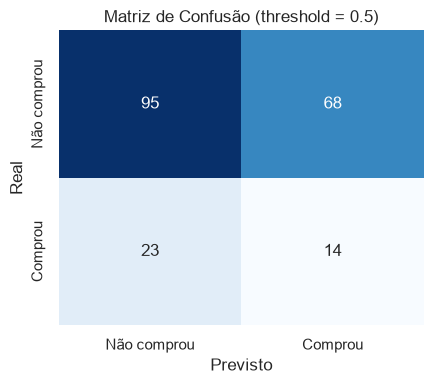

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não comprou', 'Comprou'],
            yticklabels=['Não comprou', 'Comprou'], ax=ax)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão (threshold = 0.5)')
plt.tight_layout()
plt.show()

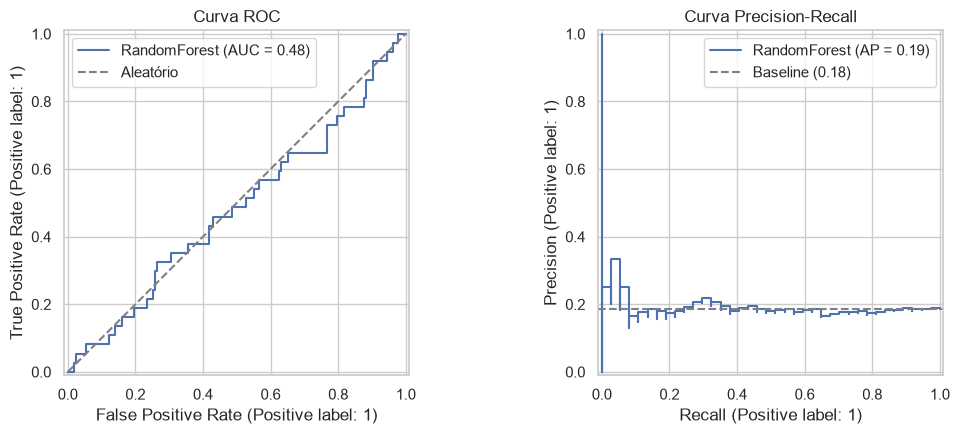

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='RandomForest')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
axes[0].set_title('Curva ROC')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='RandomForest')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

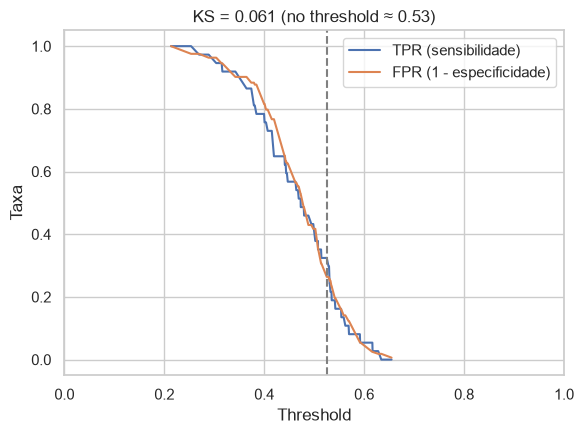

KS Statistic: 0.061  (referência de mercado em crédito/churn: <0.20 fraco, 0.20-0.40 razoável, >0.40 forte)


In [12]:
# Estatística KS: maior distância vertical entre a curva de verdadeiros
# positivos e a de falsos positivos, ao variar o threshold. É a métrica
# clássica de "poder de separação" em modelos de risco/propensão.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
ks_stat = np.max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, tpr, label='TPR (sensibilidade)')
ax.plot(thresholds, fpr, label='FPR (1 - especificidade)')
ax.axvline(thresholds[ks_idx], linestyle='--', color='gray')
ax.set_title(f'KS = {ks_stat:.3f} (no threshold ≈ {thresholds[ks_idx]:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Taxa')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"KS Statistic: {ks_stat:.3f}  (referência de mercado em crédito/churn: <0.20 fraco, 0.20-0.40 razoável, >0.40 forte)")

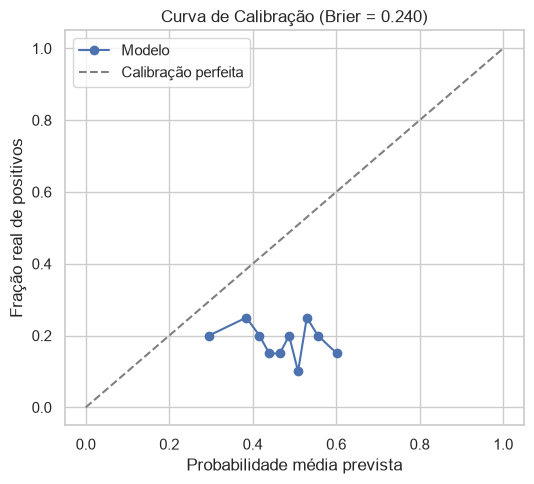

In [13]:
# Curva de calibração: a probabilidade prevista corresponde à frequência
# real observada? Importa sempre que o score entra numa conta de valor
# esperado (ex.: CLV x probabilidade), não apenas quando é usado como ranking.
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(prob_pred, prob_true, marker='o', label='Modelo')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
ax.set_xlabel('Probabilidade média prevista')
ax.set_ylabel('Fração real de positivos')
ax.set_title(f'Curva de Calibração (Brier = {brier:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

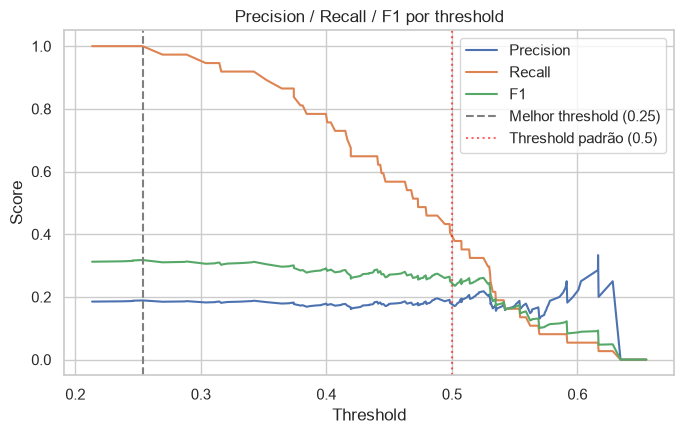

Threshold ótimo (máx. F1): 0.254
  Nesse ponto -> Precision: 0.189 | Recall: 1.000 | F1: 0.318

Nota: em um caso real, o threshold ideal deveria vir do custo da ação vs. o valor
do cliente (CLV), não só de F1 -- F1 trata falso positivo e falso negativo como
igualmente caros, o que raramente é verdade em campanhas de negócio.


In [14]:
# Otimização de threshold: 0.5 é uma convenção, não uma lei. Em classes
# desbalanceadas, o threshold que maximiza F1 (ou uma métrica de custo do
# negócio) costuma estar bem abaixo de 0.5.
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])  # último ponto não tem threshold correspondente
best_threshold = pr_thresholds[best_idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pr_thresholds, precisions[:-1], label='Precision')
ax.plot(pr_thresholds, recalls[:-1], label='Recall')
ax.plot(pr_thresholds, f1_scores[:-1], label='F1')
ax.axvline(best_threshold, linestyle='--', color='gray', label=f'Melhor threshold ({best_threshold:.2f})')
ax.axvline(0.5, linestyle=':', color='red', alpha=0.6, label='Threshold padrão (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 por threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold ótimo (máx. F1): {best_threshold:.3f}")
print(f"  Nesse ponto -> Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}")
print("\nNota: em um caso real, o threshold ideal deveria vir do custo da ação vs. o valor")
print("do cliente (CLV), não só de F1 -- F1 trata falso positivo e falso negativo como")
print("igualmente caros, o que raramente é verdade em campanhas de negócio.")

,decil,clientes,compradores,taxa_no_decil,lift,compradores_cumulativos,ganho_acumulado_%
0,1,20,3,15.0%,0.81x,3,8.1%
1,2,20,4,20.0%,1.08x,7,18.9%
2,3,20,5,25.0%,1.35x,12,32.4%
3,4,20,2,10.0%,0.54x,14,37.8%
4,5,20,4,20.0%,1.08x,18,48.6%
5,6,20,3,15.0%,0.81x,21,56.8%
6,7,20,3,15.0%,0.81x,24,64.9%
7,8,20,4,20.0%,1.08x,28,75.7%
8,9,20,5,25.0%,1.35x,33,89.2%
9,10,20,4,20.0%,1.08x,37,100.0%


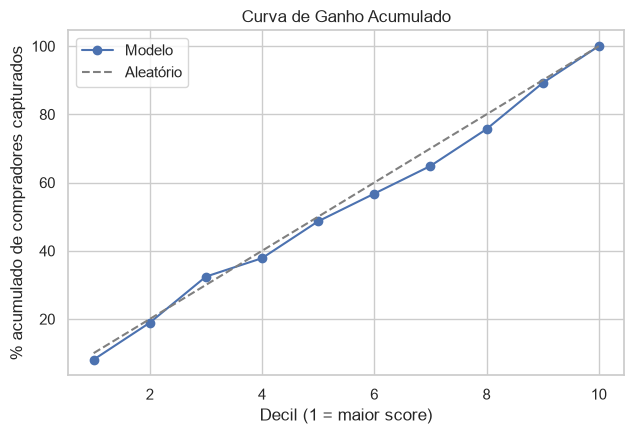

In [15]:
# Tabela de decis e lift: transforma o score em algo operacional -- "se eu
# só conseguir abordar 10% da base, quantos compradores reais eu capturo?"
resultado = pd.DataFrame({'y_real': y_test.values, 'y_proba': y_proba})
resultado = resultado.sort_values('y_proba', ascending=False).reset_index(drop=True)
resultado['decil'] = pd.qcut(resultado.index, 10, labels=False) + 1  # decil 1 = maior score

taxa_geral = resultado['y_real'].mean()

tabela_decis = resultado.groupby('decil').agg(
    clientes=('y_real', 'size'),
    compradores=('y_real', 'sum')
).reset_index()
tabela_decis['taxa_no_decil'] = tabela_decis['compradores'] / tabela_decis['clientes']
tabela_decis['lift'] = tabela_decis['taxa_no_decil'] / taxa_geral
tabela_decis['compradores_cumulativos'] = tabela_decis['compradores'].cumsum()
tabela_decis['ganho_acumulado_%'] = 100 * tabela_decis['compradores_cumulativos'] / tabela_decis['compradores'].sum()

display(tabela_decis.style.format({
    'taxa_no_decil': '{:.1%}', 'lift': '{:.2f}x', 'ganho_acumulado_%': '{:.1f}%'
}))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(tabela_decis['decil'], tabela_decis['ganho_acumulado_%'], marker='o', label='Modelo')
ax.plot([1, 10], [10, 100], linestyle='--', color='gray', label='Aleatório')
ax.set_xlabel('Decil (1 = maior score)')
ax.set_ylabel('% acumulado de compradores capturados')
ax.set_title('Curva de Ganho Acumulado')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Interpretabilidade avançada com SHAP

Além do summary plot do notebook original: importância global em barra, dependence plot da feature mais relevante, e explicações **locais** (waterfall e force plot) comparando o cliente de maior propensão prevista com o de menor.

In [16]:
# Extraímos os dados já transformados pela pipeline (sem a etapa do classificador)
# para explicar o modelo nas mesmas features com que ele foi treinado.
X_test_transformed = model_pipeline[:-1].transform(X_test)
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_model = model_pipeline.named_steps['classifier']

# O SHAP precisa de matrizes densas tradicionais para plotar
if hasattr(X_test_transformed, "toarray"):
    dados_densos = X_test_transformed.toarray()
else:
    dados_densos = X_test_transformed

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(dados_densos)


def extrair_shap_classe_positiva(shap_values):
    """Normaliza os diferentes formatos que o SHAP pode devolver para
    classificação binária e retorna sempre um array 2D (n_amostras, n_features)
    com os valores da classe 1 (comprou)."""
    if isinstance(shap_values, list):
        # Versões antigas do SHAP: lista [classe_0, classe_1]
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # Versões novas: array 3D (amostras, features, classes)
        return shap_values[:, :, 1]
    return shap_values


def extrair_base_value_classe_positiva(explainer):
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        return base_value[1] if len(base_value) > 1 else base_value[0]
    return base_value


valores_shap_classe_1 = extrair_shap_classe_positiva(shap_values)
base_value = extrair_base_value_classe_positiva(explainer)

print(f"shap_values (bruto): {type(shap_values)}, shape={np.asarray(shap_values).shape}")
print(f"valores_shap_classe_1: shape={valores_shap_classe_1.shape}")
print(f"base_value (probabilidade média prevista, escala do modelo): {base_value:.3f}")

shap_values (bruto): <class 'numpy.ndarray'>, shape=(200, 16, 2)
valores_shap_classe_1: shape=(200, 16)
base_value (probabilidade média prevista, escala do modelo): 0.500


### 8.1 Importância global — summary plot (dot) e bar plot

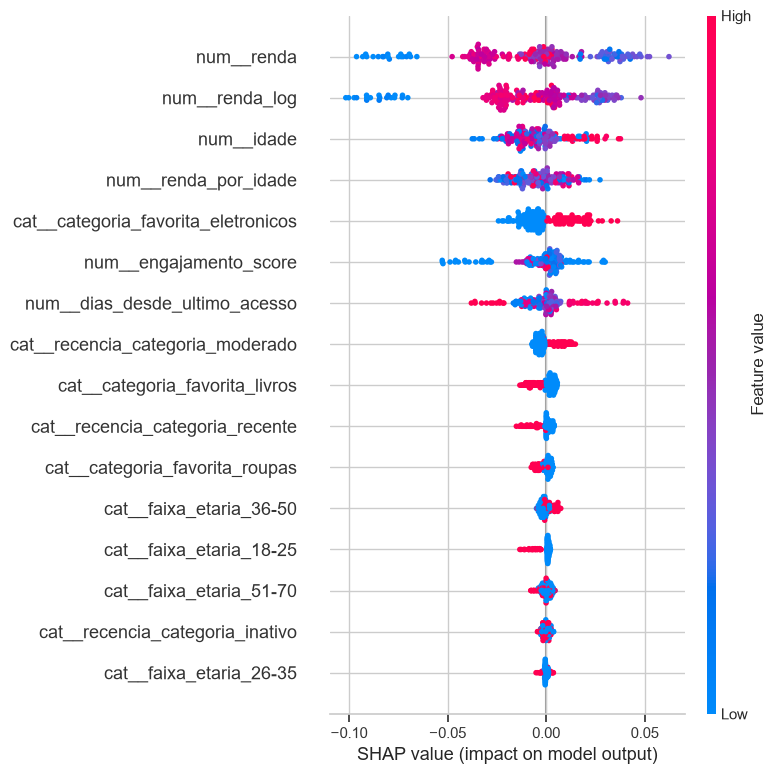

In [17]:
shap.summary_plot(
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names
)

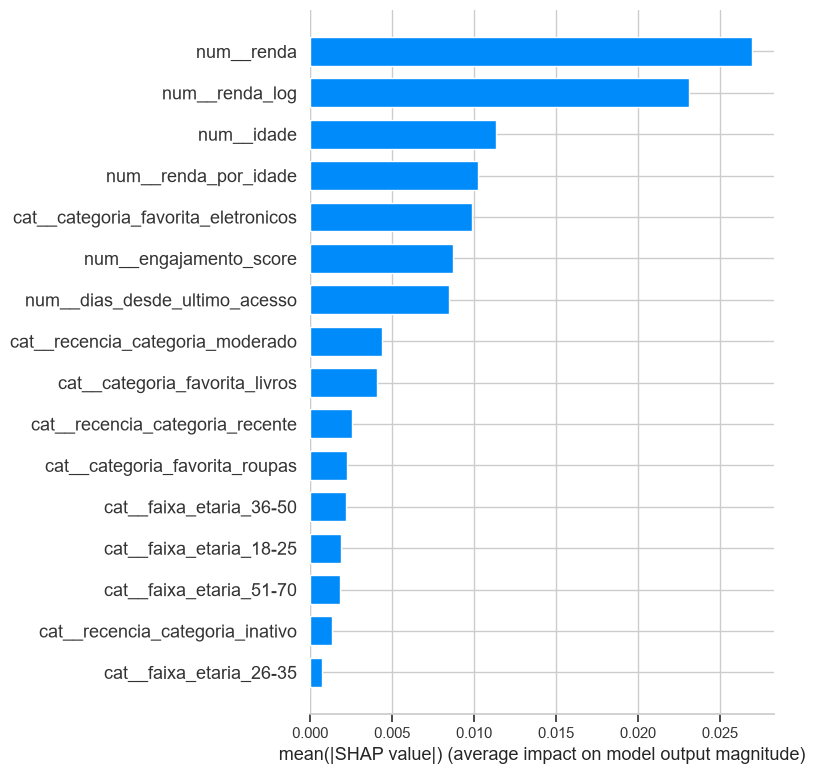

In [18]:
shap.summary_plot(
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names,
    plot_type='bar'
)

### 8.2 Dependence plot da feature mais relevante

Mostra como o valor da feature de maior impacto médio se relaciona com o SHAP value (e, por cor, com uma segunda feature que o SHAP escolhe automaticamente por interação).

Feature com maior impacto médio no modelo: num__renda


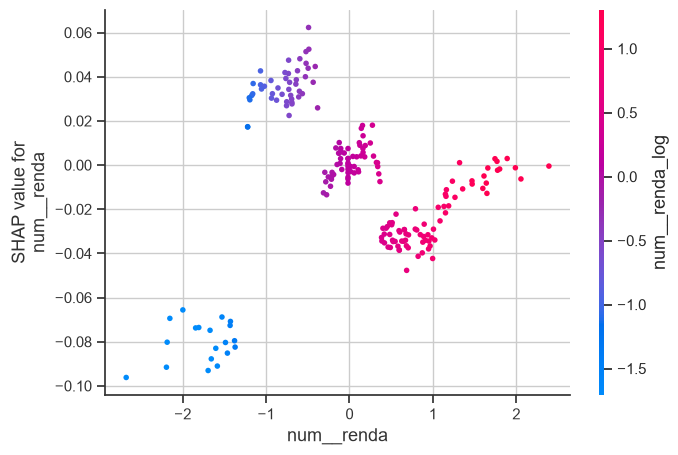

In [19]:
importancia_media = np.abs(valores_shap_classe_1).mean(axis=0)
idx_top_feature = int(np.argmax(importancia_media))
feature_top = feature_names[idx_top_feature]
print(f"Feature com maior impacto médio no modelo: {feature_top}")

shap.dependence_plot(
    idx_top_feature,
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names
)

### 8.3 Explicação local — por que o modelo deu ESSE score para ESSE cliente?

Compara, com waterfall plots, o cliente de maior propensão prevista com o de menor propensão prevista no conjunto de teste.

Cliente de maior propensão prevista (linha 190): score = 0.655
Cliente de menor propensão prevista (linha 158): score = 0.213


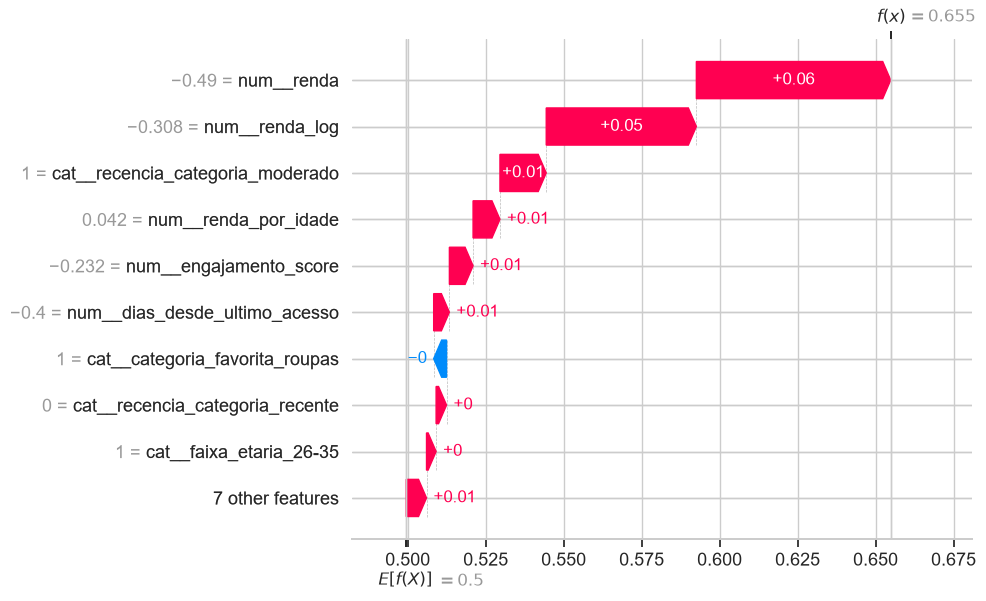

In [20]:
idx_alta_propensao = int(np.argmax(y_proba))
idx_baixa_propensao = int(np.argmin(y_proba))

print(f"Cliente de maior propensão prevista (linha {idx_alta_propensao}): score = {y_proba[idx_alta_propensao]:.3f}")
print(f"Cliente de menor propensão prevista (linha {idx_baixa_propensao}): score = {y_proba[idx_baixa_propensao]:.3f}")

explicacao_alta = shap.Explanation(
    values=valores_shap_classe_1[idx_alta_propensao],
    base_values=base_value,
    data=dados_densos[idx_alta_propensao],
    feature_names=list(feature_names)
)
shap.plots.waterfall(explicacao_alta)

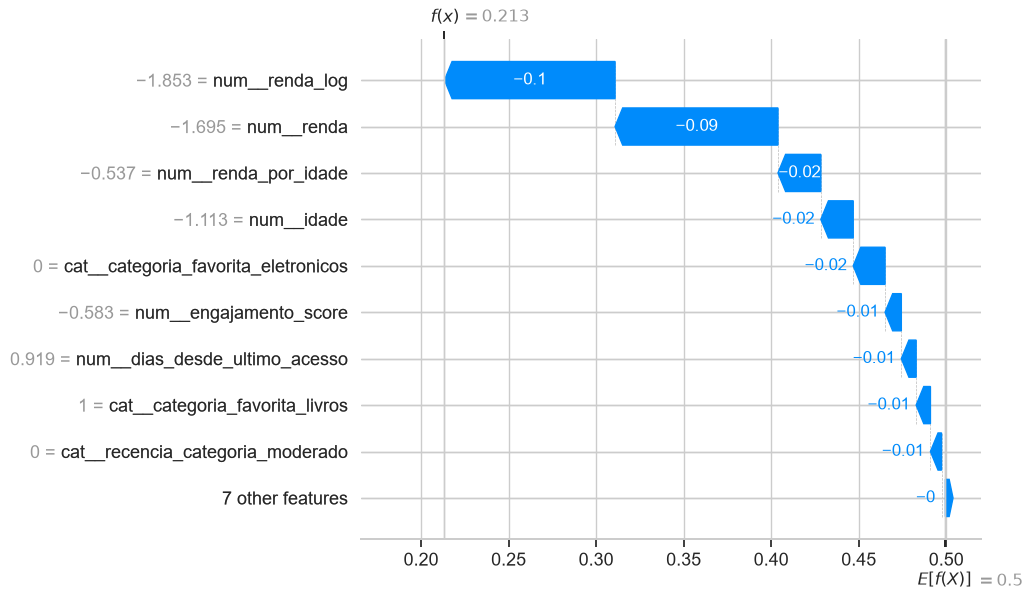

In [21]:
explicacao_baixa = shap.Explanation(
    values=valores_shap_classe_1[idx_baixa_propensao],
    base_values=base_value,
    data=dados_densos[idx_baixa_propensao],
    feature_names=list(feature_names)
)
shap.plots.waterfall(explicacao_baixa)

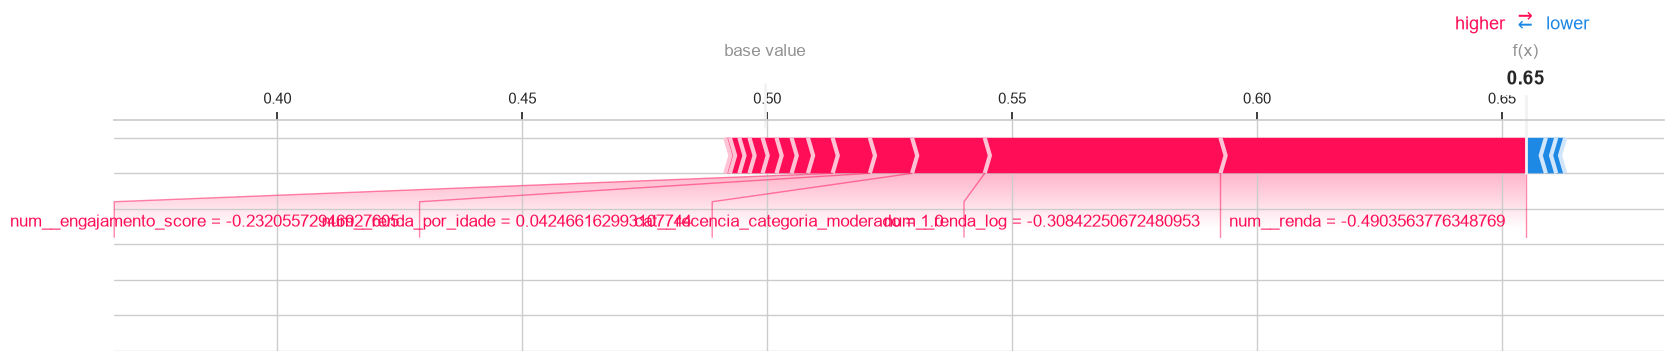

In [22]:
# Force plot: mesma informação do waterfall em outro formato visual,
# útil para relatórios/slides (é o gráfico mais usado em apresentações de negócio).
shap.force_plot(
    base_value,
    valores_shap_classe_1[idx_alta_propensao],
    dados_densos[idx_alta_propensao],
    feature_names=list(feature_names),
    matplotlib=True
)

## 9. Conclusões, limitações e próximos passos

**Sobre os números deste notebook.** Os dados são simulados aleatoriamente e não carregam relação real com o target — por isso ROC-AUC, PR-AUC e KS ficam perto do nível de base, mesmo com feature engineering, otimização de threshold e um pipeline sem vazamento. Isso foi mantido de propósito para focar na técnica; o esqueleto do notebook (engenharia de features dentro da pipeline, validação cruzada estratificada, avaliação em múltiplas camadas e interpretabilidade local/global) é o que muda de verdade quando os dados tiverem sinal real.

**Checklist para quando entrarem dados reais**, na ordem em que cada pergunta faz sentido:

1. *O modelo ordena?* — ROC-AUC, PR-AUC e KS acima do baseline da base.
2. *A lista é aproveitável?* — olhar os decis/lift pela capacidade operacional real (quantos clientes o time consegue abordar por ciclo), não pelos 10% do topo por padrão.
3. *A probabilidade significa algo?* — curva de calibração e Brier score; se o uso é só ranking, calibração ruim importa menos; se o score entra numa conta de valor esperado, vale recalibrar (Platt scaling ou regressão isotônica) antes de usar.
4. *Onde cortar?* — threshold definido pelo custo da ação e pelo valor do cliente (CLV), não por 0.5 nem só por F1.
5. *Isso vira dinheiro?* — projeção de ROI/lucro em cima da ação, tratando a eficácia da retenção como premissa até existir um teste A/B que confirme.
6. *A avaliação é honesta?* — split temporal (não aleatório) quando o problema tiver componente de tempo, e auditoria de vazamento (nenhuma feature deveria existir só depois do evento que se quer prever).
7. *A ação funciona de verdade?* — teste A/B com grupo de controle; o score sozinho não prova impacto incremental.

**Limitações conhecidas deste pipeline:**
- `RandomForestClassifier` foi usado com hiperparâmetros fixos, sem comparação com outros algoritmos nem busca de hiperparâmetros — o próximo passo natural seria testar XGBoost/LightGBM e um `RandomizedSearchCV`/`GridSearchCV` dentro da mesma validação cruzada estratificada já montada aqui.
- A imputação de nulos usa mediana/moda simples; em produção vale avaliar se a ausência em si é informativa (ex.: `renda` nula pode correlacionar com o motivo de um cadastro incompleto) e criar uma flag binária de "era nulo".
- As faixas de idade e recência usam cortes fixos de negócio; com dados reais, vale testar cortes por quantil e comparar o ganho de performance.